In [66]:
import pandas as pd
import torch
import torch.nn.functional as F
from tqdm import tqdm
from transformers import AutoModelForSequenceClassification, AutoModel, AutoTokenizer
import matplotlib.pyplot as plt

MODEL_NAME = "google-bert/bert-base-uncased"
MAX_LENGTH = 256

In [3]:
train = pd.read_csv('train_data.csv')
train.head(5)

,pair_id,py_source,cpp_source
0,pair_0000,"def f_gold ( num , divisor ) :\n while ( nu...","using namespace std;\nint f_gold ( int num, in..."
1,pair_0001,"def f_gold ( arr , n ) :\n mp = dict ( )\n ...",using namespace std;\nint f_gold ( int arr [ ]...
2,pair_0002,def f_gold ( s ) :\n length = len ( s )\n ...,using namespace std;\nint f_gold ( string str ...
3,pair_0003,"def f_gold ( arr , n ) :\n arr.sort ( ) ;\n...",using namespace std;\nint f_gold ( int arr [ ]...
4,pair_0004,"import sys\n\ndef f_gold ( arr , n ) :\n re...",using namespace std;\nint f_gold ( int arr [ ]...


In [ ]:
def encode_batch(model, tokenizer, texts, device, batch_size=32):
    all_embs = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Encoding"):
        batch = texts[i: i + batch_size]
        enc = tokenizer(
            batch,
            max_length=MAX_LENGTH,
            padding=True,
            truncation=True,
            return_tensors="pt",
        )
        with torch.no_grad():
            out = model(
                input_ids=enc["input_ids"].to(device),
                attention_mask=enc["attention_mask"].to(device),
            )
        last_hidden = out.last_hidden_state
        mask = enc["attention_mask"].unsqueeze(-1).float().to(device)
        embs = (last_hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
        all_embs.append(embs.cpu())
    return torch.cat(all_embs, dim=0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert = AutoModel.from_pretrained(MODEL_NAME).to(device)
bert.eval()

query_embs = encode_batch(bert, tokenizer, train['py_source'].tolist(), device)
cand_embs = encode_batch(bert, tokenizer, train['cpp_source'].tolist(), device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Encoding: 

AttributeError: 'SequenceClassifierOutput' object has no attribute 'last_hidden_state'

In [5]:
print(query_embs.shape, cand_embs.shape)

torch.Size([100, 768]) torch.Size([100, 768])


In [6]:
query_embs = F.normalize(query_embs, dim=1)
cand_embs = F.normalize(cand_embs, dim=1)

sim_matrix = query_embs @ cand_embs.T
sim_matrix.shape

torch.Size([100, 100])

<Axes: >

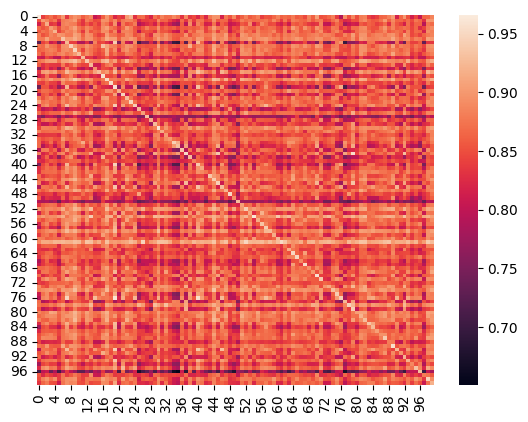

In [7]:
import seaborn as sns
sns.heatmap(sim_matrix)

In [ ]:
import numpy as np
sim_matrix.fill_diagonal_(float('-inf'))
values, indicies = torch.topk(sim_matrix.reshape(-1), 100)
indicies = np.array(indicies)
query_indicies = indicies // 100
candidate_indicies = indicies % 100

i=3
train['py_source'][query_indicies[i]], train['cpp_source'][candidate_indicies[i]], query_embs[i] @ cand_embs[i]

C:\Users\raian\AppData\Local\Temp\ipykernel_12148\506598920.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  indicies = np.array(indicies)


('def f_gold ( n ) :\n    i = 1 ;\n    res = 0.0 ;\n    sign = True ;\n    while ( n > 0 ) :\n        n = n - 1 ;\n        if ( sign ) :\n            sign = False ;\n            res = res + ( i + 1 ) / ( i + 2 ) ;\n            i = i + 2 ;\n        else :\n            sign = True ;\n            res = res - ( i + 1 ) / ( i + 2 ) ;\n            i = i + 2 ;\n    return res ;',
 'using namespace std;\ndouble f_gold ( int n ) {\n  int i = 1;\n  double res = 0.0;\n  bool sign = true;\n  while ( n > 0 ) {\n    n --;\n    if ( sign ) {\n      sign = ! sign;\n      res = res + ( double ) ++ i / ++ i;\n    }\n    else {\n      sign = ! sign;\n      res = res - ( double ) ++ i / ++ i;\n    }\n  }\n  return res;\n}',
 tensor(0.9029))

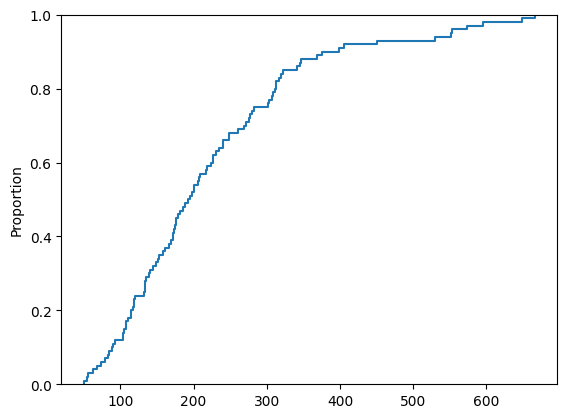

In [49]:
pos_examples = [(train['py_source'][i], train['cpp_source'][i]) for i in range(0,100)]
neg_examples = [(train['py_source'][query_indicies[i]], train['cpp_source'][candidate_indicies[i]]) for i in range(0,100)]

pos_enc = tokenizer(pos_examples, padding=False, truncation=False)
lens = [len(pos_enc.input_ids[i]) for i in range(0,100)]
sns.ecdfplot(lens)

encodings = tokenizer(pos_examples + neg_examples, padding=True, truncation=True, return_tensors="pt")

In [57]:
from datasets import Dataset

temp_ds = Dataset.from_dict({
    "input_ids": encodings["input_ids"],
    "attention_mask": encodings["attention_mask"],
    "labels": [1]*100 + [0]*100
})

split = temp_ds.train_test_split(test_size=0.1)
train_ds, val_ds = split['train'], split['test']
len(train_ds), len(val_ds)

(180, 20)

In [70]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        'accuracy': accuracy_score(labels, preds),
        'f1': f1_score(labels, preds)
    }

In [ ]:
# Optional LoRA
from peft import LoraConfig, get_peft_model, TaskType

config = LoraConfig(TaskType.SEQ_CLS, r=8, lora_alpha=16, lora_dropout=0.1, bias='none')

model = get_peft_model(bert, config)

In [74]:
from transformers import Trainer, TrainingArguments, EarlyStoppingCallback
from transformers import DataCollatorWithPadding

collator = DataCollatorWithPadding(tokenizer)

bert = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
bert.train()

args = TrainingArguments(
    learning_rate=1e-5,
    warmup_steps=100,
    weight_decay=1e-3,
    num_train_epochs=12,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='loss'
)

trainer = Trainer(bert, args, train_dataset=train_ds, eval_dataset=val_ds, data_collator=collator, compute_metrics=compute_metrics, callbacks=[EarlyStoppingCallback(2)])
trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
0,No log,0.640708,0.650000,0.588235


KeyboardInterrupt: 

In [75]:
res = trainer.evaluate()
res

{'eval_loss': 0.6407076120376587,
 'eval_accuracy': 0.65,
 'eval_f1': 0.5882352941176471}

In [ ]:

# py_proj = None
# c_proj = None
# if args.checkpoint:
#     print(f"Loading checkpoint: {args.checkpoint}")
#     ckpt = torch.load(args.checkpoint, map_location=device, weights_only=True)
#     from baseline.train import ProjectionHead

#     py_proj = ProjectionHead(ckpt["embed_dim"], ckpt["proj_dim"]).to(device)
#     c_proj = ProjectionHead(ckpt["embed_dim"], ckpt["proj_dim"]).to(device)
#     py_proj.load_state_dict(ckpt["py_proj"])
#     c_proj.load_state_dict(ckpt["c_proj"])
#     py_proj.eval()
#     c_proj.eval()


# "subtaskID", "datapointID", "answer"
for i, qid in enumerate(tqdm(query_ids, desc="Scoring")):
    sims = torch.matmul(cand_embs, query_embs[i])
    ranked_indices = torch.argsort(sims, descending=True).tolist()
    ranked_ids = [cand_ids[j] for j in ranked_indices]